In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Clean display
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_colwidth', None)

# Define paths
MODEL_PATH = "models/model_best.h5"
TOKENIZER_PATH = "data/processed/tokenizer.pkl"
DATA_PATH = "data/processed/cleaned_dataset.csv"
LOG_PATH = "models/training_log.csv"

print("✅ Libraries imported and paths set up successfully.")


✅ Libraries imported and paths set up successfully.


In [3]:
# Load model
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded successfully!")

# Load tokenizer
with open(TOKENIZER_PATH, "rb") as f:
    tokenizer = pickle.load(f)
print("✅ Tokenizer loaded successfully!")

# Load dataset
df = pd.read_csv(DATA_PATH).dropna(subset=["clean_join", "label"]).reset_index(drop=True)
print(f"✅ Dataset loaded: {df.shape[0]} samples")

df.head()


✅ Model loaded successfully!
✅ Tokenizer loaded successfully!
✅ Dataset loaded: 44919 samples


,title,text,subject,label,clean_join
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.",News,FAKE,donald trump sends embarrassing new year s eve message this disturbing donald trump couldn t wish americans happy new year leave it that instead he give shout his enemies haters dishonest fake news media former reality show star one job he couldn t it as our country rapidly grows stronger smarter i want wish my friends supporters enemies haters even dishonest fake news media happy healthy new year president angry pants tweeted great year america as our country rapidly grows stronger smarter i want wish my friends supporters enemies haters even dishonest fake news media happy healthy new year great year america donald j trump realdonaldtrump december trump s tweet went as welll as you d expect what kind president sends new year s greeting like this despicable petty infantile gibberish trump his lack decency won t even allow him rise above gutter long enough wish american citizens happy new year bishop talbert swan talbertswan december one likes you calvin calvinstowell december your 

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Clean and map labels
df["label"] = df["label"].astype(str).str.strip().str.lower()
map_dict = {"fake": 0, "false": 0, "0": 0, "real": 1, "true": 1, "1": 1}
df = df[df["label"].isin(map_dict.keys())].copy()
df["label"] = df["label"].map(map_dict)

# Tokenize & pad
seqs = tokenizer.texts_to_sequences(df["clean_join"].tolist())
lengths = [len(s) for s in seqs]
p95 = int(np.percentile(lengths, 95))
max_len = min(p95, 500)

X = pad_sequences(seqs, maxlen=max_len, padding="post", truncating="post")
y = df["label"].values

# Split same way as train1.py
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}, max_len={max_len}")


Train: (35935, 500), Val: (4492, 500), Test: (4492, 500), max_len=500


In [5]:
# Evaluate metrics
test_loss, test_acc, test_auc = model.evaluate(X_test, y_test, batch_size=64, verbose=0)

print("✅ Evaluation completed.")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")


✅ Evaluation completed.
Test Loss: 0.0328
Test Accuracy: 0.9984
Test AUC: 0.9995


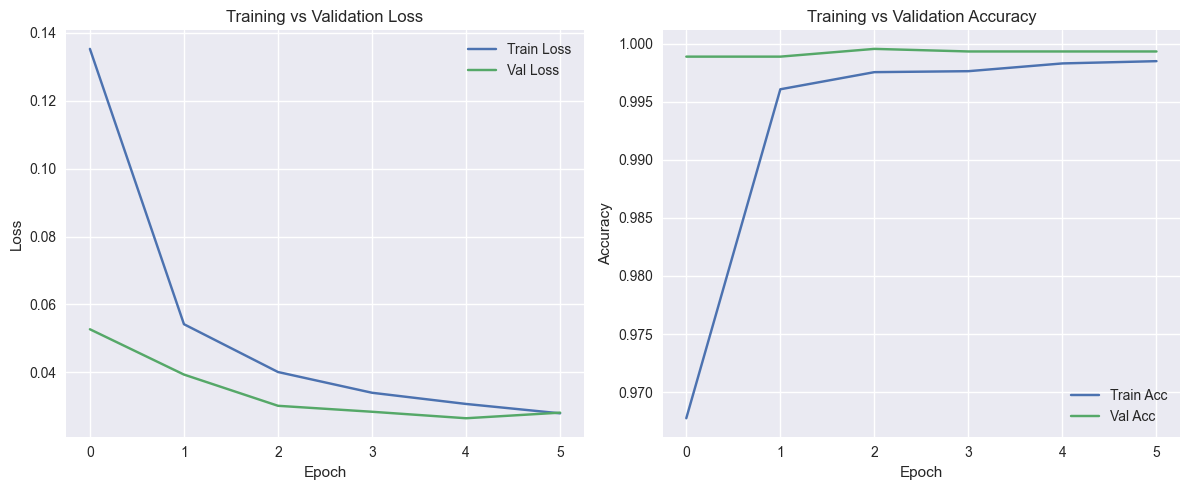

In [6]:
# Load training log
log_df = pd.read_csv(LOG_PATH)

# Plot training vs validation metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(log_df["epoch"], log_df["loss"], label="Train Loss")
axes[0].plot(log_df["epoch"], log_df["val_loss"], label="Val Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(log_df["epoch"], log_df["accuracy"], label="Train Acc")
axes[1].plot(log_df["epoch"], log_df["val_accuracy"], label="Val Acc")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


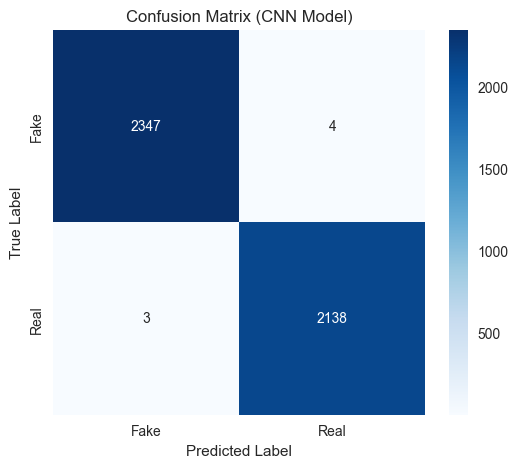


📊 Classification Report (Detailed):
              precision    recall  f1-score   support

        Fake     0.9987    0.9983    0.9985      2351
        Real     0.9981    0.9986    0.9984      2141

    accuracy                         0.9984      4492
   macro avg     0.9984    0.9984    0.9984      4492
weighted avg     0.9984    0.9984    0.9984      4492



In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on test set
y_pred = (model.predict(X_test, verbose=0) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (CNN Model)")
plt.show()

# Classification Report (với 4 chữ số thập phân)
print("\n📊 Classification Report (Detailed):")
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"], digits=4))


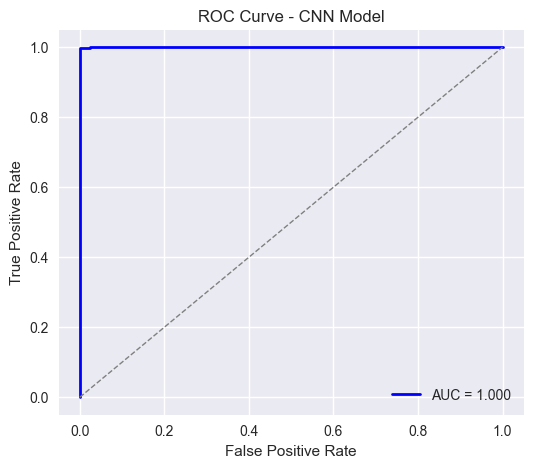

In [8]:
y_pred_prob = model.predict(X_test, verbose=0)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN Model")
plt.legend()
plt.show()


In [9]:
sample_text = "The Prime Minister announced new policies to support local businesses in 2025."
seq = tokenizer.texts_to_sequences([sample_text])
padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
pred = model.predict(padded)[0][0]

label = "Real" if pred >= 0.5 else "Fake"
confidence = pred if pred >= 0.5 else 1 - pred

print(f"\n📰 Input: {sample_text}")
print(f"Prediction: {label} ({confidence*100:.2f}% confidence)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

📰 Input: The Prime Minister announced new policies to support local businesses in 2025.
Prediction: Fake (71.55% confidence)


In [10]:
print("📋 MODEL EVALUATION SUMMARY")
print(f"• Model type: CNN (Conv1D + GlobalMaxPooling1D)")
print(f"• Total dataset: {len(df)} samples")
print(f"• Train/Val/Test split: 80/10/10")
print(f"• Max sequence length: {max_len}")
print(f"• Test Accuracy: {test_acc:.4f}")
print(f"• Test AUC: {test_auc:.4f}")
print(f"• Model path: {MODEL_PATH}")


📋 MODEL EVALUATION SUMMARY
• Model type: CNN (Conv1D + GlobalMaxPooling1D)
• Total dataset: 44919 samples
• Train/Val/Test split: 80/10/10
• Max sequence length: 500
• Test Accuracy: 0.9984
• Test AUC: 0.9995
• Model path: models/model_best.h5
